In [7]:
import json
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [37]:
with open('company_tickers.json', 'r') as f:
    data = json.load(f)

In [38]:
tickers = []
for x in data.items():
    tickers.append(x[1]['ticker'])
ticker_test = tickers[0:5]

In [39]:
import time
def fetch_stock_data(tickers):
    #all_data = {}
    infor = {}
    print('Downloading yfinance historical price data 2010/01/01 to 2025/03/16')
    for ticker in tickers:
        try:
            #all_data[ticker] = yf.download(ticker, start="2010-01-01", end="2025-03-16", progress = False, interval='1wk')
            #time.sleep(2.001)
            infor[ticker] = yf.Ticker(ticker)
            time.sleep(2.001)  # Sleep for 2 seconds between requests to avoid being blocked
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")
            time.sleep(2.001)
    return infor

In [40]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

sp500_tickers = get_sp500_tickers()

In [41]:
#Need to figure out what i want from each section so I can save as a csv.
#I can save the price data as a csv or could go without the price data and just do yf.Ticker
#Remove stocks that are too large or remove ones where the mktcap is too small
#Remove pharma companies
sp500_infor = fetch_stock_data(sp500_tickers)

In [50]:
def get_info_df(tickers, infor):
    dict_list = []
    for x in tickers:
        info = infor[x].info
        dict_list.append(info)
    df = pd.DataFrame(dict_list)
    return df

In [ ]:
sp500_df = get_info_df(sp500_tickers, sp500_infor)
sp500_df.to_csv('sp500_info.csv')


,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,...,sourceInterval,exchangeDataDelayedBy,averageAnalystRating,cryptoTradeable,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,industrySymbol
0,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,Conglomerates,...,15.0,0.0,2.2 - Buy,False,2.4980,NaN,NaN,NaN,NaN,NaN
1,11270 West Park Place,Milwaukee,WI,53224,United States,414 359 4000,https://www.aosmith.com,Specialty Industrial Machinery,specialty-industrial-machinery,Specialty Industrial Machinery,...,15.0,0.0,2.5 - Buy,False,1.5655,Suite 170,A. O. Smith,NaN,NaN,NaN


In [ ]:
df_2000 = pd.read_excel('russell_2000.xlsx')
russell2000_info = fetch_stock_data(df_2000['Ticker'])
#r2000_df = get_info_df( df_2000['Ticker'], russell2000_info)
#r2000_df.to_csv('r2000_info.csv')
#r2000_df.head(2)

In [55]:
dict_list = {}
for x in df_2000['Ticker']:
    try:
        info = russell2000_info[x].info
        dict_list[x] = info
        
    except Exception as e:
        print(f"Error downloading {x}: {e}")


In [59]:

russell_df = pd.DataFrame(dict_list).T

In [60]:
russell_df.to_csv('r2000_info.csv')

In [58]:
r2000_df = pd.read_csv('r2000_info.csv')
r2000_df.head(1)

,Unnamed: 0,address1,address2,city,state,zip,country,phone,website,industry,...,beta3Year,fundFamily,fundInceptionDate,legalType,threeYearAverageReturn,fiveYearAverageReturn,trailingThreeMonthReturns,trailingThreeMonthNavReturns,netAssets,netExpenseRatio
0,AAMI,200 Clarendon Street,53rd Floor,Boston,MA,02116,United States,617-369-7300,https://www.bsig.com,Asset Management,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
df_cleaned = r2000_df.dropna(axis=1, thresh=1500)
df_cleaned.head()

,Unnamed: 0,address1,city,state,zip,country,phone,website,industry,industryKey,...,exchangeTimezoneShortName,gmtOffSetMilliseconds,market,esgPopulated,regularMarketChangePercent,regularMarketPrice,displayName,compensationAsOfEpochDate,forwardEps,epsForward
0,AAMI,200 Clarendon Street,Boston,MA,02116,United States,617-369-7300,https://www.bsig.com,Asset Management,asset-management,...,EDT,-14400000.0,us_market,False,-1.686472,25.650,Acadian Asset Management,NaN,NaN,NaN
1,AAOI,13139 Jess Pirtle Boulevard,Sugar Land,TX,77478,United States,(281) 295-1800,https://www.ao-inc.com,Communication Equipment,communication-equipment,...,EDT,-14400000.0,us_market,False,-15.068495,11.780,Applied Optoelectronics,1.735603e+09,0.73,0.73
2,AAT,3420 Carmel Mountain Road,San Diego,CA,92121-1069,United States,858 350 2600,https://www.americanassetstrust.com,REIT - Diversified,reit-diversified,...,EDT,-14400000.0,us_market,False,-3.750683,17.835,American Assets Trust,1.703981e+09,0.72,0.72
3,ABCB,3490 Piedmont Road NE,Atlanta,GA,30305,United States,404 639 6500,https://www.amerisbank.com,Banks - Regional,banks-regional,...,EDT,-14400000.0,us_market,False,-7.686705,50.680,NaN,1.703981e+09,5.03,5.03
4,ABG,"2905 Premiere Parkway, NW",Duluth,GA,30097,United States,770 418 8200,https://www.asburyauto.com,Auto & Truck Dealerships,auto-truck-dealerships,...,EDT,-14400000.0,us_market,False,-4.427345,222.885,Asbury Automotive,1.735603e+09,27.69,27.69


In [60]:
#df_cleaned.columns.to_list()

In [61]:
dropcols = ['Unnamed: 0','address1', 'phone', 'website', 'longBusinessSummary', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'governanceEpochDate', 'executiveTeam',
 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow',
 'regularMarketDayHigh', 'payoutRatio', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'fiftyTwoWeekLow',
 'fiftyTwoWeekHigh', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendYield',
 'currency', 'tradeable', 'enterpriseValue', 'forwardPE', 'floatShares', 'sharesShort', 'sharesShortPriorMonth', 'sharesShortPreviousMonthDate',
 'dateShortInterest', 'sharesPercentSharesOut', 'shortRatio', 'shortPercentOfFloat', 'impliedSharesOutstanding', 'priceToBook', 'lastFiscalYearEnd',
 'nextFiscalYearEnd', 'mostRecentQuarter', 'netIncomeToCommon', 'trailingEps', 'enterpriseToRevenue', 'enterpriseToEbitda', '52WeekChange', 'SandP52WeekChange',
 'quoteType', 'targetHighPrice', 'targetLowPrice', 'targetMeanPrice', 'targetMedianPrice', 'recommendationKey', 'numberOfAnalystOpinions', 'revenueGrowth',
 'grossMargins', 'ebitdaMargins', 'operatingMargins', 'financialCurrency', 'language', 'region', 'typeDisp', 'quoteSourceName', 'triggerable', 'customPriceAlertConfidence',
 'marketState', 'shortName', 'longName', 'earningsTimestampEnd', 'earningsCallTimestampStart', 'earningsCallTimestampEnd', 'isEarningsDateEstimate',
 'epsTrailingTwelveMonths', 'epsCurrentYear', 'priceEpsCurrentYear', 'fiftyDayAverageChange', 'fiftyDayAverageChangePercent', 'twoHundredDayAverageChange',
 'twoHundredDayAverageChangePercent', 'sourceInterval', 'exchangeDataDelayedBy', 'cryptoTradeable', 'hasPrePostMarketData', 'firstTradeDateMilliseconds',
 'regularMarketChange',
 'regularMarketDayRange',
 'fullExchangeName',
 'averageDailyVolume3Month',
 'earningsTimestamp',
 'earningsTimestampStart',
 'corporateActions',
 'regularMarketTime',
 'exchange',
 'messageBoardId',
 'exchangeTimezoneName',
 'exchangeTimezoneShortName',
 'gmtOffSetMilliseconds',
 'market',
 'esgPopulated',
 'regularMarketChangePercent',
 'compensationAsOfEpochDate',
 'epsForward',
 'industryKey',
 'industryDisp',
 'sectorKey',
 'sectorDisp']
df_small = df_cleaned.drop(dropcols, axis = 1)

In [62]:
df_small.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,regularMarketPrice,displayName,forwardEps
0,Boston,MA,02116,United States,Asset Management,Financial Services,383.0,1.0,2.0,1.354,...,AAMI,4.199999,0.195804,21.45 - 31.52,-5.870001,-0.186231,15.493584,25.650,Acadian Asset Management,NaN
1,Sugar Land,TX,77478,United States,Communication Equipment,Technology,3309.0,8.0,7.0,2.573,...,AAOI,5.080000,0.758209,6.7 - 44.5,-32.720000,-0.735281,16.456758,11.780,Applied Optoelectronics,0.73
2,San Diego,CA,92121-1069,United States,REIT - Diversified,Real Estate,226.0,9.0,5.0,1.150,...,AAT,1.144999,0.068604,16.69 - 29.15,-11.315001,-0.388165,-11.929655,17.835,American Assets Trust,0.72
3,Atlanta,GA,30305,United States,Banks - Regional,Financial Services,2691.0,2.0,2.0,0.878,...,ABCB,6.450001,0.145829,44.23 - 74.56,-23.879997,-0.320279,21.031750,50.680,NaN,5.03
4,Duluth,GA,30097,United States,Auto & Truck Dealerships,Consumer Cyclical,15000.0,6.0,3.0,1.045,...,ABG,21.205002,0.105142,201.68 - 312.56,-89.675000,-0.286905,5.821764,222.885,Asbury Automotive,27.69


In [63]:
sp500_df = pd.read_csv('sp500_info.csv')
sp500_df.head(1)

,Unnamed: 0,address1,city,state,zip,country,phone,website,industry,industryKey,...,sourceInterval,exchangeDataDelayedBy,averageAnalystRating,cryptoTradeable,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,industrySymbol
0,0,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,...,15.0,0.0,2.2 - Buy,False,2.498,NaN,NaN,NaN,NaN,NaN


In [64]:
small_sp500 = sp500_df.drop(dropcols, axis = 1)#.dropna(axis=1, thresh=450)
small_sp500.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,irWebsite,...,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,dividendDate,averageAnalystRating,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,industrySymbol
0,Saint Paul,MN,55144-1000,United States,Conglomerates,Industrials,61500.0,4.0,9.0,http://phx.corporate-ir.net/phoenix.zhtml?c=80...,...,-0.148385,48.443880,1.741738e+09,2.2 - Buy,2.4980,NaN,NaN,NaN,NaN,NaN
1,Milwaukee,WI,53224,United States,Specialty Industrial Machinery,Industrials,12700.0,10.0,10.0,http://investor.shareholder.com/aosmith/,...,-0.319849,-27.382475,1.739837e+09,2.5 - Buy,1.5655,Suite 170,A. O. Smith,NaN,NaN,NaN
2,North Chicago,IL,60064-6400,United States,Medical Devices,Healthcare,114000.0,2.0,7.0,http://www.abbottinvestor.com/phoenix.zhtml?c=...,...,-0.117814,13.988340,1.747267e+09,1.8 - Buy,NaN,Abbott Park,NaN,NaN,NaN,NaN
3,North Chicago,IL,60064-6400,United States,Drug Manufacturers - General,Healthcare,55000.0,9.0,7.0,NaN,...,-0.205616,7.354343,1.747267e+09,2.0 - Buy,0.3765,NaN,AbbVie,NaN,NaN,NaN
4,Dublin,NaN,D02 P820,Ireland,Information Technology Services,Technology,801000.0,4.0,2.0,http://investor.accenture.com/phoenix.zhtml?c=...,...,-0.282729,-7.764691,1.747267e+09,1.8 - Buy,2.5405,Grand Canal Harbour,Accenture,353 1 646 2020,NaN,NaN


In [66]:
condition_sp500 = small_sp500[(small_sp500['beta'] > 1) & (small_sp500['freeCashflow'] >= 0) & (small_sp500['sector'] != 'Healthcare')]

In [67]:
import matplotlib.pyplot as plt

<Axes: xlabel='sector'>

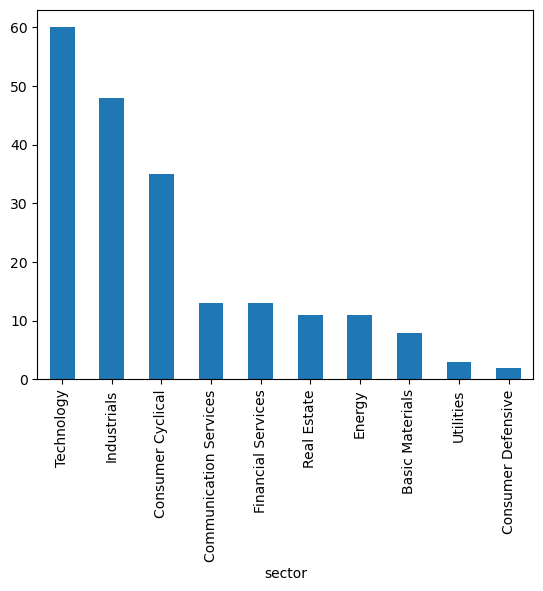

In [68]:
condition_sp500['sector'].value_counts().plot(kind='bar')

In [69]:
condition_russ = df_small[(df_small['beta'] > 1) & (df_small['freeCashflow'] >= 0) & (df_small['sector'] != 'Healthcare')]

<Axes: xlabel='sector'>

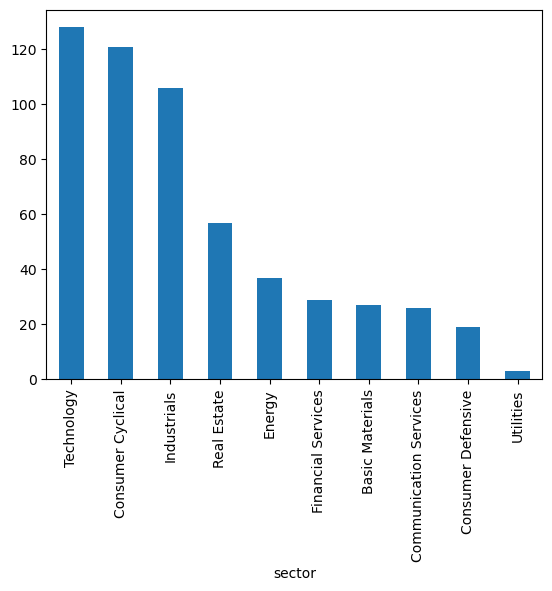

In [70]:
condition_russ['sector'].value_counts().plot(kind='bar')

<Axes: >

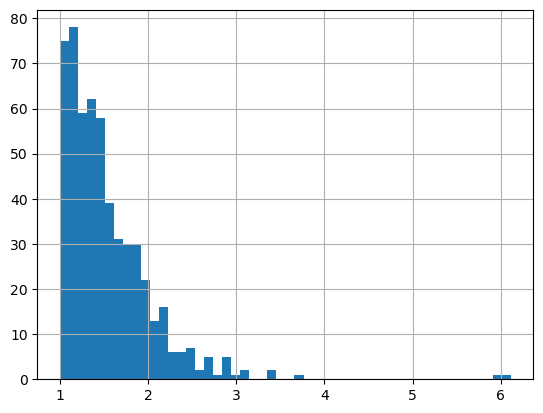

In [71]:
condition_russ['beta'].hist(bins=50)

In [72]:
condition_russ[condition_russ['beta'] > 4]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,regularMarketPrice,displayName,forwardEps
1061,Fort Lauderdale,FL,33301,United States,Capital Markets,Financial Services,152.0,4.0,9.0,6.114,...,MARA,1.929999,0.196738,9.81 - 30.28,-18.540000,-0.612285,-30.056816,11.74,MARA,0.04
1356,New York,NY,10017,United States,Software - Infrastructure,Technology,553.0,NaN,NaN,5.919,...,PGY,1.250000,0.152439,8.2 - 19.2,-9.750001,-0.507812,-11.518324,9.45,Pagaya,0.50


<Axes: >

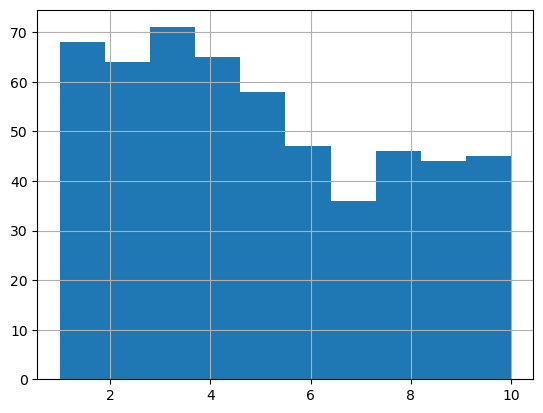

In [73]:
condition_russ['overallRisk'].hist(bins=10)

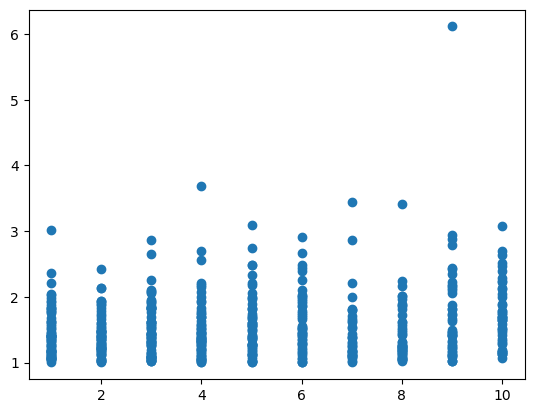

In [74]:
plt.scatter(data = condition_russ, x = 'overallRisk', y = 'beta')

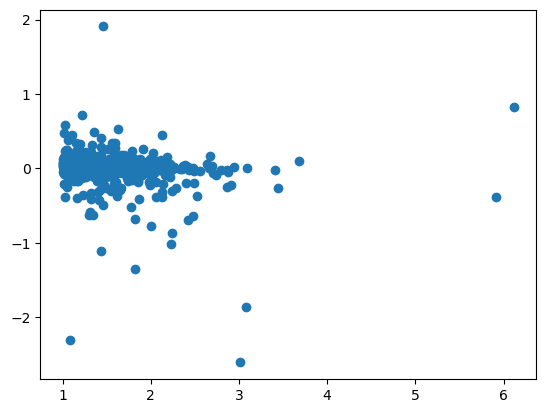

In [76]:
plt.scatter(data = condition_russ, x = 'beta', y = 'profitMargins')

In [77]:
condition_russ[condition_russ['profitMargins'] > 1]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,regularMarketPrice,displayName,forwardEps
1586,Beachwood,OH,44122-7200,United States,REIT - Retail,Real Estate,172.0,2.0,4.0,1.452,...,SITC,0.935,0.089431,10.455 - 64.44,-53.050003,-0.823246,-79.01657,11.39,SITE Centers,-0.74


<Axes: >

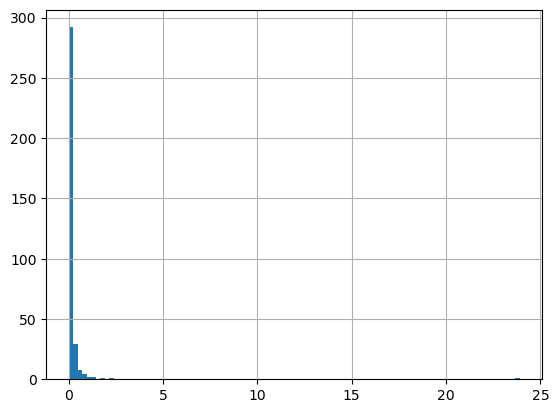

In [78]:
condition_russ[condition_russ['returnOnEquity'] > 0]['returnOnEquity'].hist(bins=100)

In [79]:
condition_russ[condition_russ['returnOnEquity'] > 20]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,regularMarketPrice,displayName,forwardEps
549,Dallas,TX,75019,United States,Restaurants,Consumer Cyclical,68852.0,1.0,1.0,2.215,...,EAT,99.23001,2.287987,43.37 - 192.22,-49.619995,-0.258142,213.59058,142.6,Brinker,6.2


<Axes: >

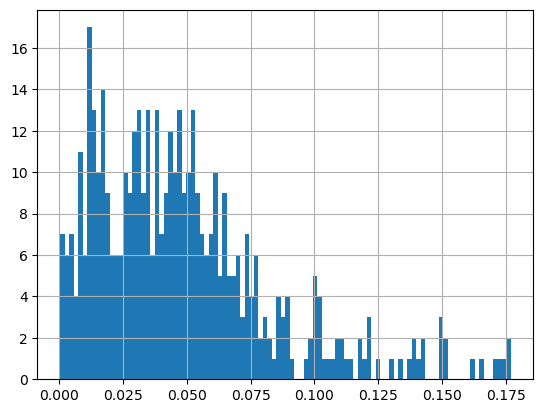

In [80]:
condition_russ[condition_russ['returnOnAssets'] > 0]['returnOnAssets'].hist(bins=100)

<Axes: xlabel='sector'>

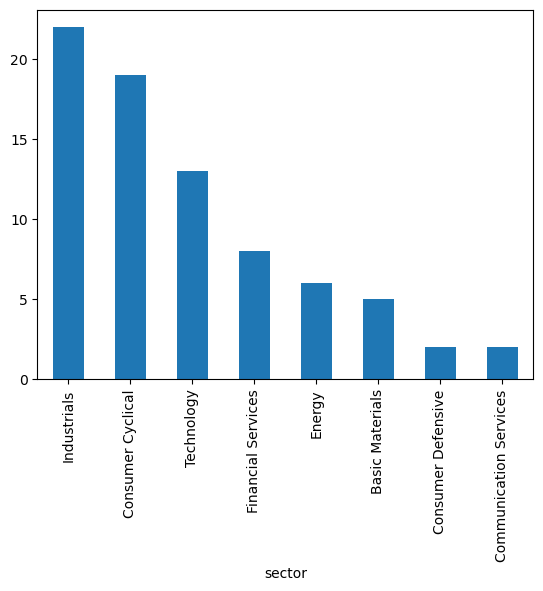

In [81]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['sector'].value_counts().plot(kind='bar')

<Axes: >

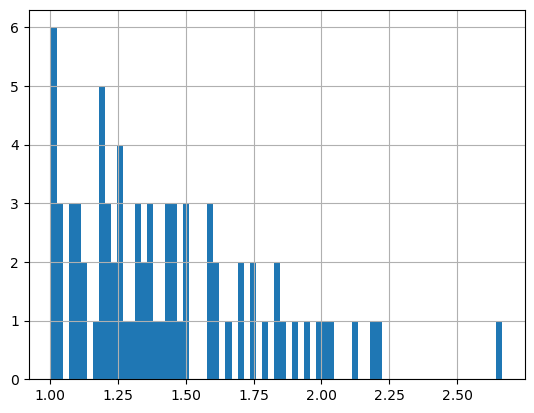

In [82]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['beta'].hist(bins=75)

<Axes: >

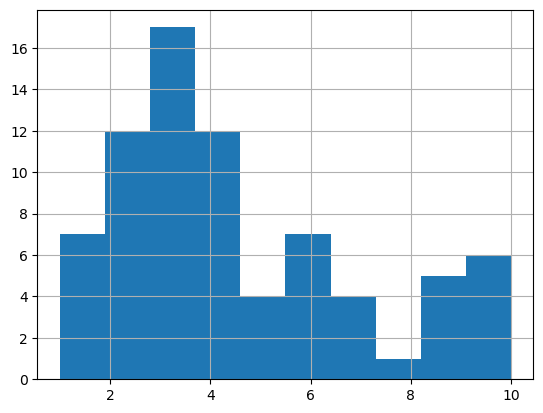

In [83]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['overallRisk'].hist(bins=10)

<Axes: >

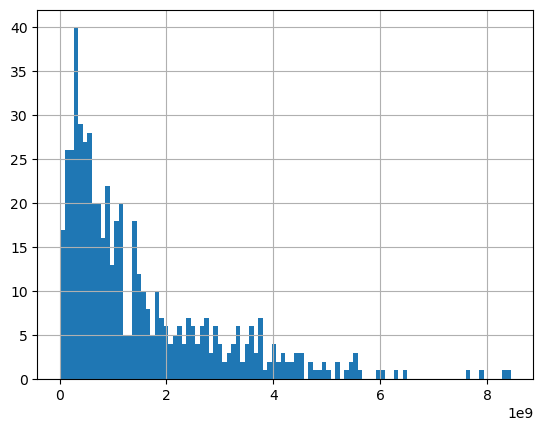

In [84]:
condition_russ['marketCap'].hist(bins = 100)

<Axes: >

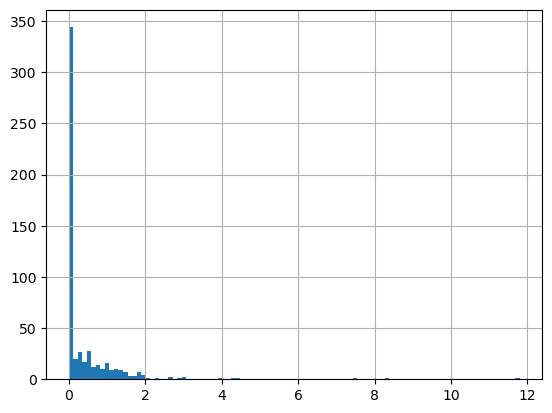

In [85]:
condition_russ['trailingAnnualDividendRate'].hist(bins = 100)

In [87]:
condition_sp500['revPerEmp'] = condition_sp500['totalRevenue']/condition_sp500['fullTimeEmployees']
condition_russ['revPerEmp'] = condition_russ['totalRevenue']/condition_russ['fullTimeEmployees']

C:\Users\owenh\AppData\Local\Temp\ipykernel_47736\1898315872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condition_sp500['revPerEmp'] = condition_sp500['totalRevenue']/condition_sp500['fullTimeEmployees']
C:\Users\owenh\AppData\Local\Temp\ipykernel_47736\1898315872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condition_russ['revPerEmp'] = condition_russ['totalRevenue']/condition_russ['fullTimeEmployees']


<Axes: >

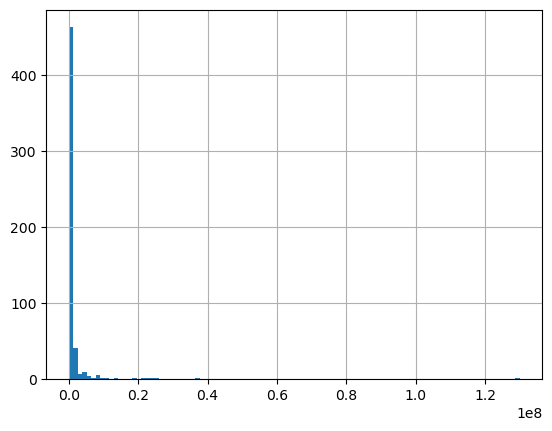

In [88]:
condition_russ['revPerEmp'].hist(bins = 100)

<Axes: >

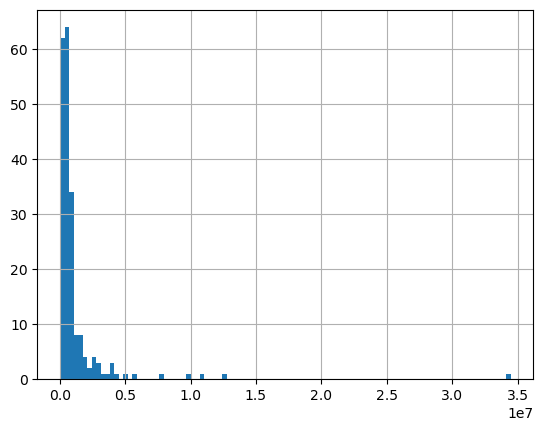

In [89]:
condition_sp500['revPerEmp'].hist(bins = 100)

In [90]:
russ_q3 = condition_russ['revPerEmp'].quantile(0.75)

# Filter rows where 'Score' is in the top quartile
top_quartile_russ = condition_russ[condition_russ['revPerEmp'] >= russ_q3]
top_quartile_russ = top_quartile_russ[(top_quartile_russ['bookValue'] > 0) & (top_quartile_russ['profitMargins'] > 0)]
top_quartile_russ.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,regularMarketPrice,displayName,forwardEps,revPerEmp
0,Boston,MA,02116,United States,Asset Management,Financial Services,383.0,1.0,2.0,1.354,...,4.199999,0.195804,21.45 - 31.52,-5.870001,-0.186231,15.493584,25.650,Acadian Asset Management,NaN,1.320104e+06
2,San Diego,CA,92121-1069,United States,REIT - Diversified,Real Estate,226.0,9.0,5.0,1.150,...,1.144999,0.068604,16.69 - 29.15,-11.315001,-0.388165,-11.929655,17.835,American Assets Trust,0.72,2.005925e+06
4,Duluth,GA,30097,United States,Auto & Truck Dealerships,Consumer Cyclical,15000.0,6.0,3.0,1.045,...,21.205002,0.105142,201.68 - 312.56,-89.675000,-0.286905,5.821764,222.885,Asbury Automotive,27.69,1.145907e+06
15,Burr Ridge,IL,60527,United States,Gambling,Consumer Cyclical,1500.0,6.0,5.0,1.355,...,1.674999,0.185801,9.015 - 12.96,-2.270001,-0.175154,-4.634583,10.690,Accel Entertainment,0.86,8.206480e+05
30,San Jose,CA,95134,United States,Software - Application,Technology,150.0,4.0,2.0,1.122,...,2.109900,0.217963,9.6801 - 17.46,-5.669999,-0.324742,20.365036,11.790,Adeia,1.36,2.506827e+06


In [91]:
sp500_q3 = condition_sp500['revPerEmp'].quantile(0.75)

# Filter rows where 'Score' is in the top quartile
top_quartile_sp500 = condition_sp500[condition_sp500['revPerEmp'] >= sp500_q3]
top_quartile_sp500 = top_quartile_sp500[(top_quartile_sp500['bookValue'] > 0) & (top_quartile_sp500['profitMargins'] > 0)]
top_quartile_sp500.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,irWebsite,...,fiftyTwoWeekChangePercent,dividendDate,averageAnalystRating,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,industrySymbol,revPerEmp
6,Santa Clara,CA,95054,United States,Semiconductors,Technology,28000.0,3.0,5.0,http://phx.corporate-ir.net/phoenix.zhtml?c=74...,...,-43.202347,NaN,1.9 - Buy,0.3842,NaN,Advanced Micro Devices,NaN,NaN,NaN,9.208929e+05
11,San Francisco,CA,94103,United States,Travel Services,Consumer Cyclical,7300.0,10.0,10.0,NaN,...,-26.659410,NaN,2.6 - Hold,1.8764,NaN,Airbnb,NaN,2020-12-10,NaN,1.520822e+06
14,Pasadena,CA,91101-6104,United States,REIT - Office,Real Estate,552.0,7.0,8.0,NaN,...,-34.769978,1.744675e+09,2.5 - Buy,NaN,NaN,Alexandria Real Estate Equities,626 578 0896,NaN,NaN,5.658429e+06
19,Mountain View,CA,94043,United States,Internet Content & Information,Communication Services,183323.0,10.0,10.0,NaN,...,-0.439119,1.742170e+09,1.6 - Buy,1.1431,NaN,NaN,NaN,NaN,NaN,1.909297e+06
20,Mountain View,CA,94043,United States,Internet Content & Information,Communication Services,183323.0,NaN,NaN,NaN,...,0.167918,1.742170e+09,1.6 - Buy,1.1600,NaN,Alphabet,NaN,NaN,NaN,1.909297e+06


In [95]:
drop_cols_2 = ['city', 'state', 'zip',
       'fullTimeEmployees', 'shareHolderRightsRisk', 
       'irWebsite',  'exDividendDate',
       'fiveYearAvgDividendYield',  'volume',
       'regularMarketVolume', 'averageVolume', 
       'trailingAnnualDividendRate',  'sharesOutstanding',
       'heldPercentInsiders', 'heldPercentInstitutions', 
       'earningsQuarterlyGrowth', 'forwardEps', 'lastSplitFactor',
       'lastSplitDate', 'lastDividendValue', 'lastDividendDate',
       'recommendationMean', 'totalCash', 'totalCashPerShare',
       'regularMarketPrice', 'fiftyTwoWeekLowChange',
       'fiftyTwoWeekLowChangePercent', 'fiftyTwoWeekRange',
       'fiftyTwoWeekHighChange', 'fiftyTwoWeekHighChangePercent',
       'fiftyTwoWeekChangePercent', 'dividendDate', 'trailingPegRatio', 'address2', 'fax', 'ipoExpectedDate',
       'industrySymbol']
drop_cols_2_russ = ['city', 'state', 'zip', 'country', 
       'fullTimeEmployees', 'shareHolderRightsRisk',
       'volume', 'regularMarketVolume', 'averageVolume', 'sharesOutstanding',
       'heldPercentInsiders', 'heldPercentInstitutions', 'fiftyTwoWeekLowChange',
       'fiftyTwoWeekLowChangePercent', 'fiftyTwoWeekRange',
       'fiftyTwoWeekHighChange', 'fiftyTwoWeekHighChangePercent',
       'fiftyTwoWeekChangePercent', 'regularMarketPrice',
       'forwardEps']


In [96]:
top_quartile_sp500 = top_quartile_sp500.drop(drop_cols_2, axis = 1)
top_quartile_russ = top_quartile_russ.drop(drop_cols_2_russ, axis = 1)

<Axes: >

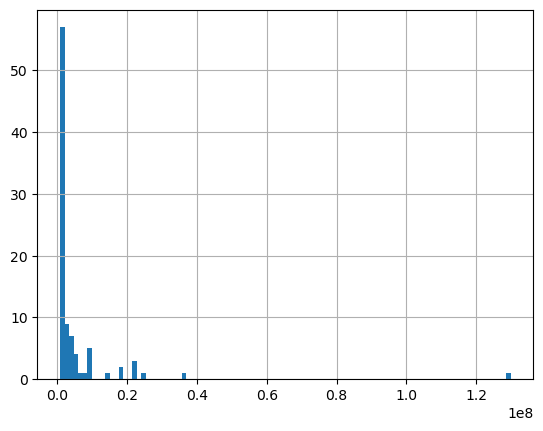

In [99]:
top_quartile_russ['revPerEmp'].hist(bins = 100)

<Axes: >

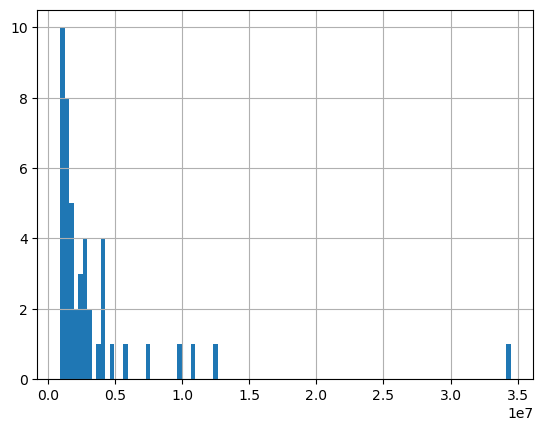

In [100]:
top_quartile_sp500['revPerEmp'].hist(bins = 100)

In [102]:
liquid_sp500 = top_quartile_sp500[top_quartile_sp500['quickRatio'] >= 1]
liquid_russ = top_quartile_russ[top_quartile_russ['quickRatio'] >= 1]

In [ ]:
picks = liquid_sp500.merge(liquid_russ, how = 'outer')

,country,industry,sector,overallRisk,dividendRate,dividendYield,beta,trailingPE,marketCap,profitMargins,...,freeCashflow,operatingCashflow,earningsGrowth,symbol,averageAnalystRating,displayName,revPerEmp,trailingAnnualDividendRate,totalCash,totalCashPerShare
0,NaN,Apparel Manufacturing,Consumer Cyclical,7.0,NaN,NaN,1.634,NaN,1.087865e+09,0.06085,...,2.273215e+08,3.164010e+08,NaN,GIII,NaN,G-III Apparel,9.087988e+05,0.000,181440000.0,4.135
1,NaN,Apparel Manufacturing,Consumer Cyclical,10.0,NaN,NaN,1.187,NaN,6.346406e+08,0.00490,...,6.555762e+07,8.116200e+07,NaN,FIGS,NaN,FIGS,1.833525e+06,0.000,245114000.0,1.508
2,NaN,Asset Management,Financial Services,1.0,NaN,NaN,1.255,NaN,1.164620e+09,0.15592,...,9.302075e+07,1.134610e+08,NaN,WT,NaN,WisdomTree,1.366572e+06,0.120,266630000.0,1.875
3,NaN,Asset Management,Financial Services,2.0,NaN,NaN,1.354,NaN,9.507506e+08,0.16812,...,1.387125e+08,5.580000e+07,NaN,AAMI,NaN,Acadian Asset Management,1.320104e+06,0.040,94800000.0,2.529
4,NaN,Asset Management,Financial Services,3.0,NaN,NaN,1.438,NaN,3.734209e+09,0.29235,...,1.573071e+08,9.668900e+07,NaN,CNS,NaN,Cohen & Steers,1.258922e+06,2.360,309927008.0,6.081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,NaN,Thermal Coal,Energy,3.0,NaN,NaN,1.424,NaN,3.604578e+09,0.13059,...,2.249509e+08,4.763900e+08,NaN,CNR,NaN,Core Natural Resources,1.056470e+06,0.500,460232992.0,8.520
77,United States,Travel Services,Consumer Cyclical,10.0,NaN,NaN,1.152,27.817518,7.103780e+10,0.23852,...,3.145625e+09,4.518000e+09,NaN,ABNB,2.6 - Hold,Airbnb,1.520822e+06,NaN,NaN,NaN
78,NaN,Uranium,Energy,8.0,NaN,NaN,1.263,NaN,1.014624e+09,0.16561,...,3.648750e+07,3.700000e+07,NaN,LEU,NaN,Centrus Energy,1.372671e+06,0.000,671400000.0,40.047
79,NaN,Utilities - Regulated Water,Utilities,9.0,NaN,NaN,1.811,NaN,1.433569e+09,0.06168,...,5.650062e+07,1.788760e+08,NaN,ARIS,NaN,Aris Water,1.577696e+06,0.405,28673000.0,0.926


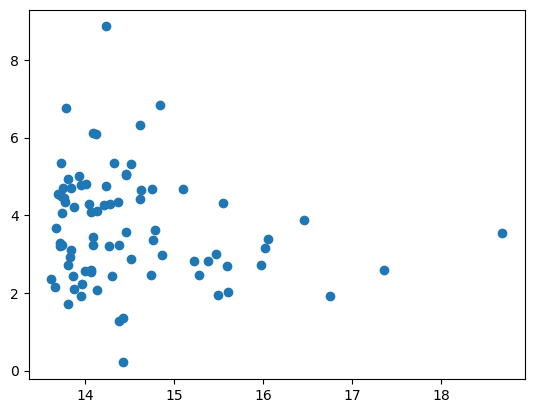

In [108]:
import numpy as np
plt.scatter(x = np.log(picks['revPerEmp']), y = np.log(picks['currentPrice']))

In [113]:
picks = picks[picks['operatingCashflow'] > 0]

In [116]:
drop_cols_3 = ['country', 'dividendYield', 'trailingPE','earningsGrowth', 'averageAnalystRating', 'trailingAnnualDividendRate', 'totalCash','totalCashPerShare']

In [117]:
picks.drop(drop_cols_3, axis= 1, inplace=True)

C:\Users\owenh\AppData\Local\Temp\ipykernel_47736\445430239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  picks.drop(drop_cols_3, axis= 1, inplace=True)


In [122]:
picks_q2 = picks['bookValue'].quantile(0.5)

# Filter rows where 'Score' is in the top quartile
picks_bv5 = picks[picks['bookValue'] >= picks_q2]


In [123]:
picks_sectors = picks_bv5['sector'].unique()
for x in picks_sectors:
    print(x)
    print(picks_bv5[ picks_bv5['sector'] == x ].to_string())

Consumer Cyclical
                    industry             sector  overallRisk  dividendRate   beta     marketCap  profitMargins  bookValue  currentPrice        ebitda     totalDebt  quickRatio  currentRatio  totalRevenue  debtToEquity  revenuePerShare  returnOnAssets  returnOnEquity  grossProfits  freeCashflow  operatingCashflow symbol       displayName     revPerEmp
0      Apparel Manufacturing  Consumer Cyclical          7.0           NaN  1.634  1.087865e+09        0.06085     38.268        24.790  3.287140e+08  2.776840e+08       1.579         2.616  3.180796e+09        16.534           71.559         0.07292         0.11978  1.298526e+09  2.273215e+08       3.164010e+08   GIII     G-III Apparel  9.087988e+05
19    Footwear & Accessories  Consumer Cyclical          3.0           NaN  1.068  1.677786e+10        0.19137     17.335       110.545  1.226205e+09  2.570290e+08       2.489         3.170  4.923590e+09         9.770           32.250         0.19807         0.39797  2.845371

In [124]:
picks_bv5.to_csv('top_picks.csv')